<a href="https://colab.research.google.com/github/qaiserfatmi/Dengue/blob/main/Dengue_ML_Analysis_New.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Analysis for Dengue from following published Paper**

Iqbal NT, Ahmed K, Khalid A, Imtiaz
K, Ali QM, Munir T, et al. (2025) Clinical
characteristics and serotype association of
dengue and dengue like illness in Pakistan.
PLoS Negl Trop Dis 19(5): e0012978. https://
doi.org/10.1371/journal.pntd.0012978

**Step 1 — Install and import required packages**

In [3]:
!pip install -q xgboost openpyxl mlxtend shap umap-learn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.metrics import silhouette_score

from xgboost import XGBClassifier, XGBRegressor

import shap
import warnings
warnings.filterwarnings("ignore")

**Step 2 — Upload the Excel file**

In [5]:
# Use if you want to Browse File from computer

#from google.colab import files
#uploaded = files.upload()

In [6]:
# Use if you want to directly Read the Excel file from Google colab, after uploading in content folder.

url = "https://journals.plos.org/plosntds/article/file?type=supplementary&id=10.1371/journal.pntd.0012978.s006"
df = pd.read_excel(url)
df.head()

# df = pd.read_excel("/content/journal.pntd.0012978.s006.xlsx")


,N#,Year,Aim,UWARN Sample ID,Inpatient/ Outpatient,Days of Illness,Age,Gender,Clinician I Diagnosis,Clinician II Diagnosis,...,Diarrhea,Heavy menstrual bleed,Blood in stool,Blood in urine,cough,Gum bleeding,Rash,Platelet transfusion,eGFR,Days of Hospitalization
0,0,2.0,1.0,B1-D01-21028-EDT,Outpatient,6.0,27.0,Female,Zika virus infection,Dengue without Warning Signs,...,No,No,No,No,No,No,No,No,No,0.0
1,1,2.0,1.0,B1-D01-11001-EDT,Inpatient,9.0,44.0,Female,Dengue fever,Dengue with warning signs,...,No,Yes,No,No,No,No,No,No,>60,4.0
2,2,2.0,1.0,B1-D01-11002-EDT,Inpatient,7.0,46.0,Female,Dengue fever,Dengue without Warning Signs,...,No,No,No,No,No,No,No,No,>60,2.0
3,3,2.0,1.0,B1-D01-11003-EDT,Inpatient,4.0,12.0,Female,Dengue fever,Dengue without Warning Signs,...,No,No,No,No,No,No,No,No,No,2.0
4,4,2.0,1.0,B1-D01-21001-EDT,Outpatient,5.0,40.0,Male,Acute Viral fever,Dengue with warning signs,...,No,No,No,No,No,No,No,No,>60,0.0


**Step 3 — Check dataset size, sheets, and columns**

In [7]:
df.shape

(352, 78)

In [8]:
df.head()

,N#,Year,Aim,UWARN Sample ID,Inpatient/ Outpatient,Days of Illness,Age,Gender,Clinician I Diagnosis,Clinician II Diagnosis,...,Diarrhea,Heavy menstrual bleed,Blood in stool,Blood in urine,cough,Gum bleeding,Rash,Platelet transfusion,eGFR,Days of Hospitalization
0,0,2.0,1.0,B1-D01-21028-EDT,Outpatient,6.0,27.0,Female,Zika virus infection,Dengue without Warning Signs,...,No,No,No,No,No,No,No,No,No,0.0
1,1,2.0,1.0,B1-D01-11001-EDT,Inpatient,9.0,44.0,Female,Dengue fever,Dengue with warning signs,...,No,Yes,No,No,No,No,No,No,>60,4.0
2,2,2.0,1.0,B1-D01-11002-EDT,Inpatient,7.0,46.0,Female,Dengue fever,Dengue without Warning Signs,...,No,No,No,No,No,No,No,No,>60,2.0
3,3,2.0,1.0,B1-D01-11003-EDT,Inpatient,4.0,12.0,Female,Dengue fever,Dengue without Warning Signs,...,No,No,No,No,No,No,No,No,No,2.0
4,4,2.0,1.0,B1-D01-21001-EDT,Outpatient,5.0,40.0,Male,Acute Viral fever,Dengue with warning signs,...,No,No,No,No,No,No,No,No,>60,0.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352 entries, 0 to 351
Data columns (total 78 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   N#                                    350 non-null    object        
 1   Year                                  349 non-null    float64       
 2   Aim                                   349 non-null    float64       
 3   UWARN Sample ID                       349 non-null    object        
 4   Inpatient/ Outpatient                 349 non-null    object        
 5   Days of Illness                       318 non-null    float64       
 6   Age                                   349 non-null    float64       
 7   Gender                                349 non-null    object        
 8   Clinician I Diagnosis                 340 non-null    object        
 9   Clinician II Diagnosis                349 non-null    object        
 10  Fi

In [10]:
df.columns.tolist()

['N#',
 'Year ',
 'Aim',
 'UWARN Sample ID',
 'Inpatient/ Outpatient',
 'Days of Illness',
 'Age ',
 'Gender',
 'Clinician I Diagnosis',
 'Clinician II Diagnosis',
 'Final Diagnosis',
 'Sample Collection Date  (DD/MM/YYYY)',
 'Final Dx (Peter)',
 'Peter Diagnosis',
 'NS-1 antigen',
 'IgM Antibody',
 'DENV Dx Results',
 'RNaseP PCR',
 'RNaseP Cq Value',
 'DENV PCR ',
 'DENV Cq Value',
 'ZIKV PCR ',
 'ZIKV Cq Value',
 'DENV Serotype',
 'DV1',
 'DV2',
 'DV3',
 'DV4',
 ' Fever or chills ',
 'Days of Fever',
 'Fever or chills onset date',
 'Currently symptomatic?',
 'Fever or chills resolution date',
 'Weight Kg',
 'Systolic Blood Pressure',
 'Diastolic Blood Pressure',
 'Pulse',
 'Temperature (c)',
 'Respiratory rate',
 'Pulse oxygen %',
 'Hemotocrit (%)',
 'WBC_count (10^9/L)',
 'Lymph_count (%)',
 'Neut_count  (%)',
 'Hemoglobin (g/dl)',
 'Platelet        (10^9/L)',
 'Thrombocytopenia Grade',
 'NLR',
 'ALT (IU/L)',
 'AST (IU/L)',
 'BUN  (mg/dl)',
 'Creatinine     (mg/dl)',
 'BACTERIA',
 

**Step 4 — Clean column names**

In [11]:
# Store original names for comparison
original_columns = df.columns.tolist()

# Clean column names
df.columns = (
    df.columns
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", "_", regex=True)
    .str.replace(r"[^\w]", "_", regex=True)
    .str.replace(r"_+", "_", regex=True)
    .str.strip("_")
)

# Check whether cleaning created duplicate names
duplicates = df.columns[df.columns.duplicated()].tolist()

print("Cleaned columns:")
print(df.columns.tolist())

print("\nDuplicate columns:")
print(duplicates)

Cleaned columns:
['n', 'year', 'aim', 'uwarn_sample_id', 'inpatient_outpatient', 'days_of_illness', 'age', 'gender', 'clinician_i_diagnosis', 'clinician_ii_diagnosis', 'final_diagnosis', 'sample_collection_date_dd_mm_yyyy', 'final_dx_peter', 'peter_diagnosis', 'ns_1_antigen', 'igm_antibody', 'denv_dx_results', 'rnasep_pcr', 'rnasep_cq_value', 'denv_pcr', 'denv_cq_value', 'zikv_pcr', 'zikv_cq_value', 'denv_serotype', 'dv1', 'dv2', 'dv3', 'dv4', 'fever_or_chills', 'days_of_fever', 'fever_or_chills_onset_date', 'currently_symptomatic', 'fever_or_chills_resolution_date', 'weight_kg', 'systolic_blood_pressure', 'diastolic_blood_pressure', 'pulse', 'temperature_c', 'respiratory_rate', 'pulse_oxygen', 'hemotocrit', 'wbc_count_10_9_l', 'lymph_count', 'neut_count', 'hemoglobin_g_dl', 'platelet_10_9_l', 'thrombocytopenia_grade', 'nlr', 'alt_iu_l', 'ast_iu_l', 'bun_mg_dl', 'creatinine_mg_dl', 'bacteria', 'alt_class', 'ast_class', 'population_density', 'humidity', 'hospitalization', 'hypertension'

**Step 5 — Inspect important diagnostic columns**

In [12]:
for col in df.columns:
    if any(keyword in col.lower() for keyword in [
        "pcr", "ns", "igm", "igg", "diagnosis",
        "serotype", "hospital", "severity", "dengue"
    ]):
        print("\nCOLUMN:", col)
        print(df[col].value_counts(dropna=False).head(20))
        print("-" * 70)


COLUMN: clinician_i_diagnosis
clinician_i_diagnosis
Dengue fever                                                            247
Fever                                                                    30
NaN                                                                      12
Viral Fever                                                               6
Viral fever                                                               5
Suspected Dengue fever                                                    4
Dengue like illness                                                       3
Enteric fever                                                             2
URTI                                                                      2
Upper respiratory tract infection                                         2
Suspected Dengue                                                          2
Acute Gastroenteritis                                                     2
Suspected EBV reactivation         

**Step 6 — Select the correct DENV PCR column**

In [13]:
pcr_col = "denv_pcr"

df[pcr_col].value_counts(dropna=False)

,count
denv_pcr,
Positive,203
Negative,80
NaN,69


**Step 7 — Convert DENV PCR result into binary target**

In [14]:
def convert_pcr_result(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().lower()

    if x in ["positive", "pos", "+", "1", "1.0", "yes", "detected"]:
        return 1

    if x in ["negative", "neg", "-", "0", "0.0", "no", "not detected"]:
        return 0

    return np.nan

df["PCR_positive"] = df[pcr_col].apply(convert_pcr_result)

df["PCR_positive"].value_counts(dropna=False)

,count
PCR_positive,
1.0,203
0.0,80
NaN,69


**Step 8 — Keep only PCR-tested patients**

In [15]:
df_pcr = df.dropna(subset=["PCR_positive"]).copy()
df_pcr["PCR_positive"] = df_pcr["PCR_positive"].astype(int)

df_pcr["PCR_positive"].value_counts()

,count
PCR_positive,
1,203
0,80


**Step 9 — Remove diagnostic leakage columns**

In [16]:
# This is the most important scientific correction. When predicting PCR positivity, do not include variables that directly reveal diagnosis.

leakage_keywords = [
    "pcr", "cq", "ct", "serotype", "denv",
    "diagnosis", "dx", "ns_1", "ns1", "igm", "igg",
    "final", "positive", "negative", "rnasep", "zikv",
    "dv1", "dv2", "dv3", "dv4"
]

leakage_cols = [
    col for col in df_pcr.columns
    if any(keyword in col.lower() for keyword in leakage_keywords)
]

leakage_cols

['clinician_i_diagnosis',
 'clinician_ii_diagnosis',
 'final_diagnosis',
 'sample_collection_date_dd_mm_yyyy',
 'final_dx_peter',
 'peter_diagnosis',
 'ns_1_antigen',
 'igm_antibody',
 'denv_dx_results',
 'rnasep_pcr',
 'rnasep_cq_value',
 'denv_pcr',
 'denv_cq_value',
 'zikv_pcr',
 'zikv_cq_value',
 'denv_serotype',
 'dv1',
 'dv2',
 'dv3',
 'dv4',
 'bacteria',
 'PCR_positive']

In [17]:
# Create features and target:

X = df_pcr.drop(columns=leakage_cols, errors="ignore")
y = df_pcr["PCR_positive"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (283, 57)
y shape: (283,)
PCR_positive
1    203
0     80
Name: count, dtype: int64


**Step 10 — Remove ID, date, sample, and administrative columns**

In [53]:
# ---------------------------------------------------------
# Step 10 — Remove ID/date/sample/admin and unwanted variables
# ---------------------------------------------------------

# Remove administrative/sample/date columns
admin_drop_cols = [
    "n",
    "uwarn_sample_id",
    "sample_collection_date_dd_mm_yyyy",
    "fever_or_chills_onset_date",
    "fever_or_chills_resolution_date"
]

X = X.drop(columns=admin_drop_cols, errors="ignore")

# Remove variables you do not want to use in the model
unwanted_cols = [
    "year",
    "aim",
    "age",
    "weight_kg",
    "population_density",
    "humidity"
]

X = X.drop(columns=unwanted_cols, errors="ignore")

print("Final X shape after correction:", X.shape)
print("Remaining columns:")
print(X.columns.tolist())

Final X shape after correction: (283, 22)
Remaining columns:
['fever_or_chills', 'days_of_fever', 'systolic_blood_pressure', 'diastolic_blood_pressure', 'pulse', 'temperature_c', 'respiratory_rate', 'hemotocrit', 'platelet_10_9_l', 'alt_iu_l', 'ast_iu_l', 'alt_class', 'ast_class', 'diabetes', 'cardiovascular_disease', 'fever', 'headache', 'bodyache', 'diarrhea', 'cough', 'rash', 'egfr']


**Step 11 — Separate numeric and categorical features**

In [55]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print(numeric_features)

print("\nCategorical features:", len(categorical_features))
print(categorical_features)

Numeric features: 9
['days_of_fever', 'systolic_blood_pressure', 'diastolic_blood_pressure', 'pulse', 'temperature_c', 'respiratory_rate', 'hemotocrit', 'platelet_10_9_l', 'ast_iu_l']

Categorical features: 13
['fever_or_chills', 'alt_iu_l', 'alt_class', 'ast_class', 'diabetes', 'cardiovascular_disease', 'fever', 'headache', 'bodyache', 'diarrhea', 'cough', 'rash', 'egfr']


**Step 12 — Fix mixed categorical data types**

In [56]:
# Encoders require their input argument must be uniformly strings or numbers

X_fixed = X.copy()

for col in categorical_features:
    X_fixed[col] = X_fixed[col].astype(str)

print("X_fixed shape:", X_fixed.shape)

X_fixed shape: (283, 22)


**Step 13 — Build preprocessing pipeline**

In [57]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    sparse_threshold=0
)

**Step 14 — Train-test split**

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X_fixed,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\ny_train distribution:")
print(y_train.value_counts())

print("\ny_test distribution:")
print(y_test.value_counts())

X_train: (212, 22)
X_test: (71, 22)

y_train distribution:
PCR_positive
1    152
0     60
Name: count, dtype: int64

y_test distribution:
PCR_positive
1    51
0    20
Name: count, dtype: int64


**Step 15 — Define ML models**

In [59]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ),

    "SVM": SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ),

    "kNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Naive Bayes": GaussianNB(),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
}

**Step 16 — Train and evaluate models**

In [60]:
results = []

for name, model in models.items():
    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    try:
        y_prob = clf.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    except Exception:
        auc = np.nan

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1_score": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": auc
    })

results_df = pd.DataFrame(results).sort_values("ROC_AUC", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1_score,ROC_AUC
5,Naive Bayes,0.394366,0.900000,0.176471,0.295082,0.711275
4,kNN,0.746479,0.800000,0.862745,0.830189,0.698529
2,Random Forest,0.760563,0.783333,0.921569,0.846847,0.698529
0,Logistic Regression,0.718310,0.816327,0.784314,0.800000,0.695098
3,SVM,0.676056,0.804348,0.725490,0.762887,0.632353
6,XGBoost,0.690141,0.754386,0.843137,0.796296,0.616667
1,Decision Tree,0.605634,0.734694,0.705882,0.720000,0.527941


**Figure 1. Bar plot of model performance**

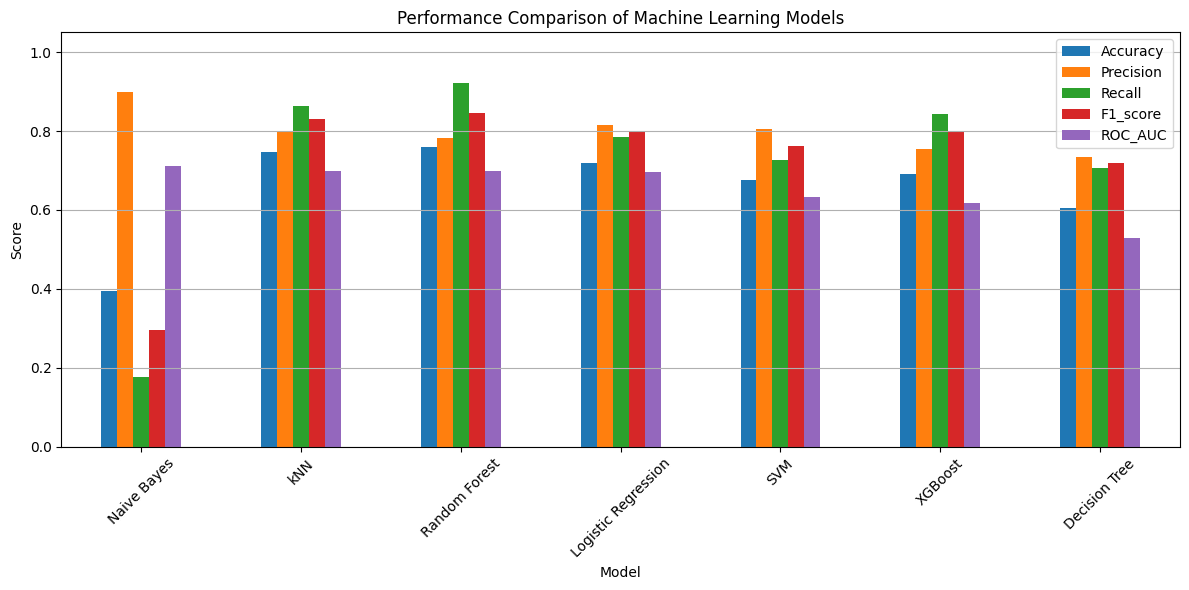

In [61]:
results_df_plot = results_df.set_index("Model")
results_df_plot[["Accuracy","Precision","Recall","F1_score","ROC_AUC"]].plot(
    kind="bar",
    figsize=(12,6)
)
plt.ylabel("Score")
plt.title("Performance Comparison of Machine Learning Models")
plt.xticks(rotation=45)
plt.ylim(0,1.05)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

**Figure 2. ROC Curves**

In [62]:
# Modify the training loop slightly to save probabilities.

roc_results = {}
results = []
for name, model in models.items():
    clf = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    try:
        y_prob = clf.predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test,y_prob)
        roc_results[name] = y_prob
    except:
        auc = np.nan
    results.append({
        "Model":name,
        "Accuracy":accuracy_score(y_test,y_pred),
        "Precision":precision_score(y_test,y_pred),
        "Recall":recall_score(y_test,y_pred),
        "F1_score":f1_score(y_test,y_pred),
        "ROC_AUC":auc
    })

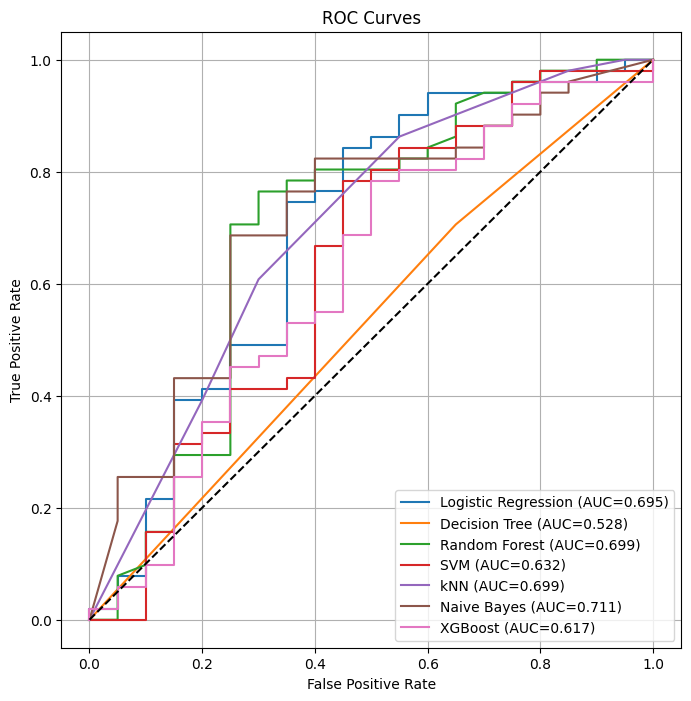

In [63]:
# plot ROC curves

from sklearn.metrics import roc_curve
plt.figure(figsize=(8,8))
for name,y_prob in roc_results.items():
    fpr,tpr,_ = roc_curve(y_test,y_prob)
    auc = roc_auc_score(y_test,y_prob)
    plt.plot(fpr,tpr,label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid()
plt.show()

**Figure 3. Confusion Matrix**

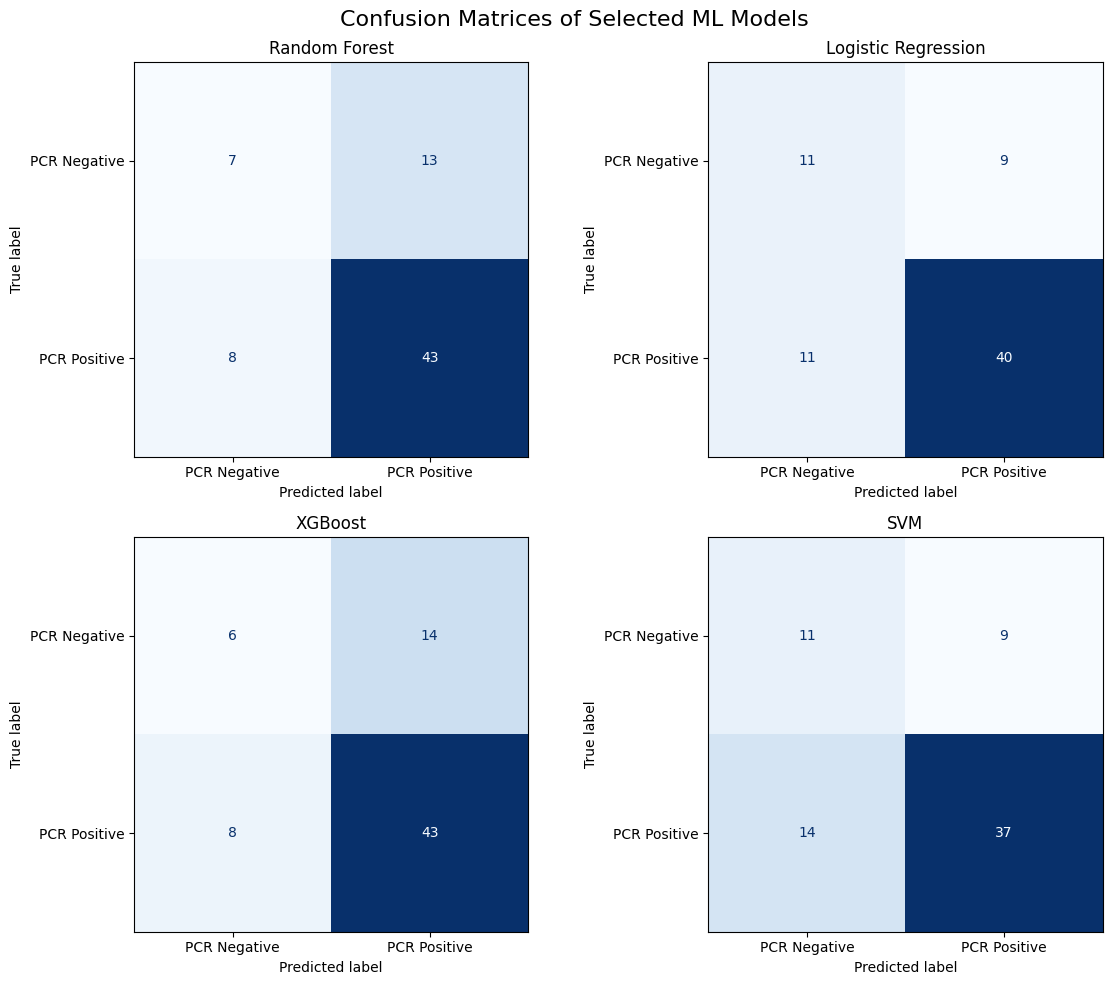

In [64]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models_cm = {
    "Random Forest": RandomForestClassifier(random_state=42),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ),

    "SVM": SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    )
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (name, model) in zip(axes, models_cm.items()):

    clf = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    clf.fit(X_train, y_train)

    ConfusionMatrixDisplay.from_estimator(
        clf,
        X_test,
        y_test,
        display_labels=["PCR Negative", "PCR Positive"],
        cmap="Blues",
        ax=ax,
        colorbar=False
    )

    ax.set_title(name)

plt.suptitle("Confusion Matrices of Selected ML Models", fontsize=16)
plt.tight_layout()
plt.show()

**Figure 4. Precision-Recall Curves**

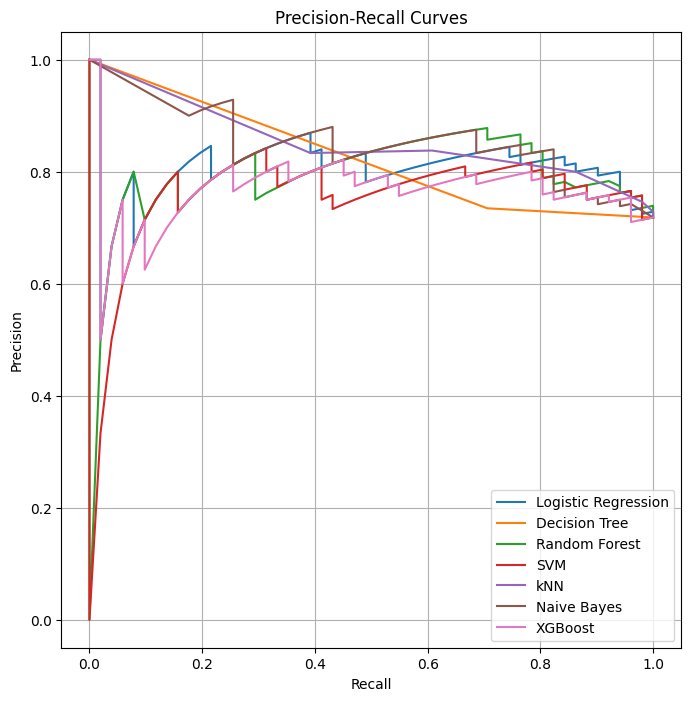

In [65]:
from sklearn.metrics import precision_recall_curve
plt.figure(figsize=(8,8))
for name,y_prob in roc_results.items():
    precision,recall,_ = precision_recall_curve(
        y_test,
        y_prob
    )
    plt.plot(recall,precision,label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid()
plt.show()

**Figure 5. Heatmap of Metrics**

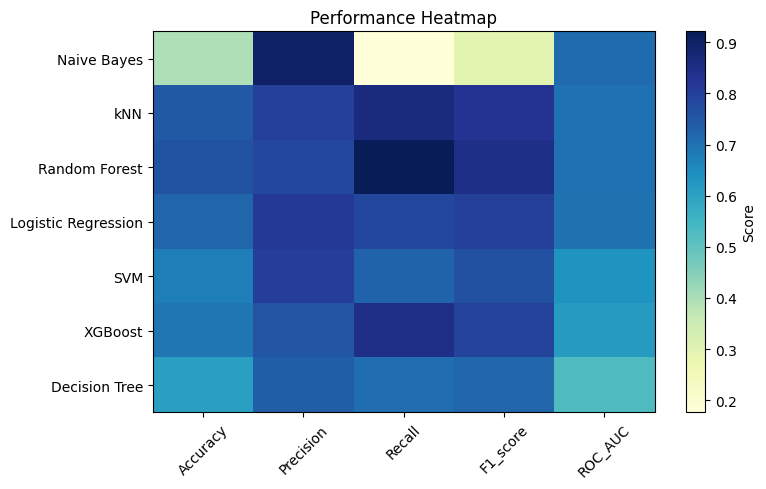

In [66]:
import matplotlib.pyplot as plt
metrics = results_df.set_index("Model")
plt.figure(figsize=(8,5))
plt.imshow(metrics,cmap="YlGnBu",aspect="auto")
plt.colorbar(label="Score")
plt.xticks(range(len(metrics.columns)),metrics.columns,rotation=45)
plt.yticks(range(len(metrics.index)),metrics.index)
plt.title("Performance Heatmap")
plt.tight_layout()
plt.show()

**Figure 6. Feature Importance**


Random Forest


,Feature_cleaned,Feature_original,Importance,SD
8,platelet_10_9_l,Platelet (10^9/L),0.090172,0.037820
9,alt_iu_l,ALT (IU/L),0.029240,0.013009
5,temperature_c,Temperature (c),0.019755,0.008397
6,respiratory_rate,Respiratory rate,0.018382,0.013297
21,egfr,eGFR,0.012230,0.016952
1,days_of_fever,Days of Fever,0.009853,0.021655
18,diarrhea,Diarrhea,0.009755,0.005334
10,ast_iu_l,AST (IU/L),0.007525,0.012520
11,alt_class,ALT class,0.005245,0.005624
14,cardiovascular_disease,Cardiovascular disease,0.004975,0.006615



Logistic Regression


,Feature_cleaned,Feature_original,Importance,SD
8,platelet_10_9_l,Platelet (10^9/L),0.094559,0.049418
9,alt_iu_l,ALT (IU/L),0.045833,0.018247
5,temperature_c,Temperature (c),0.039853,0.025811
14,cardiovascular_disease,Cardiovascular disease,0.012059,0.012791
21,egfr,eGFR,0.003627,0.010175
11,alt_class,ALT class,0.003627,0.011650
0,fever_or_chills,Fever or chills,0.001471,0.017959
10,ast_iu_l,AST (IU/L),0.001176,0.004738
18,diarrhea,Diarrhea,0.000980,0.002103
19,cough,cough,0.000294,0.002301



XGBoost


,Feature_cleaned,Feature_original,Importance,SD
8,platelet_10_9_l,Platelet (10^9/L),0.139216,0.057651
21,egfr,eGFR,0.034853,0.019651
5,temperature_c,Temperature (c),0.030686,0.022382
6,respiratory_rate,Respiratory rate,0.008627,0.008135
11,alt_class,ALT class,0.001912,0.001258
0,fever_or_chills,Fever or chills,0.000000,0.000000
20,rash,Rash,0.000000,0.000000
18,diarrhea,Diarrhea,0.000000,0.000000
14,cardiovascular_disease,Cardiovascular disease,0.000000,0.000000
12,ast_class,AST class,0.000000,0.000000



SVM


,Feature_cleaned,Feature_original,Importance,SD
8,platelet_10_9_l,Platelet (10^9/L),0.133873,0.055318
5,temperature_c,Temperature (c),0.044069,0.021361
21,egfr,eGFR,0.022451,0.018552
9,alt_iu_l,ALT (IU/L),0.010539,0.006390
10,ast_iu_l,AST (IU/L),0.008627,0.010625
18,diarrhea,Diarrhea,0.003922,0.004148
19,cough,cough,0.002794,0.004485
0,fever_or_chills,Fever or chills,0.002696,0.006137
6,respiratory_rate,Respiratory rate,0.002010,0.002267
11,alt_class,ALT class,0.000637,0.002198


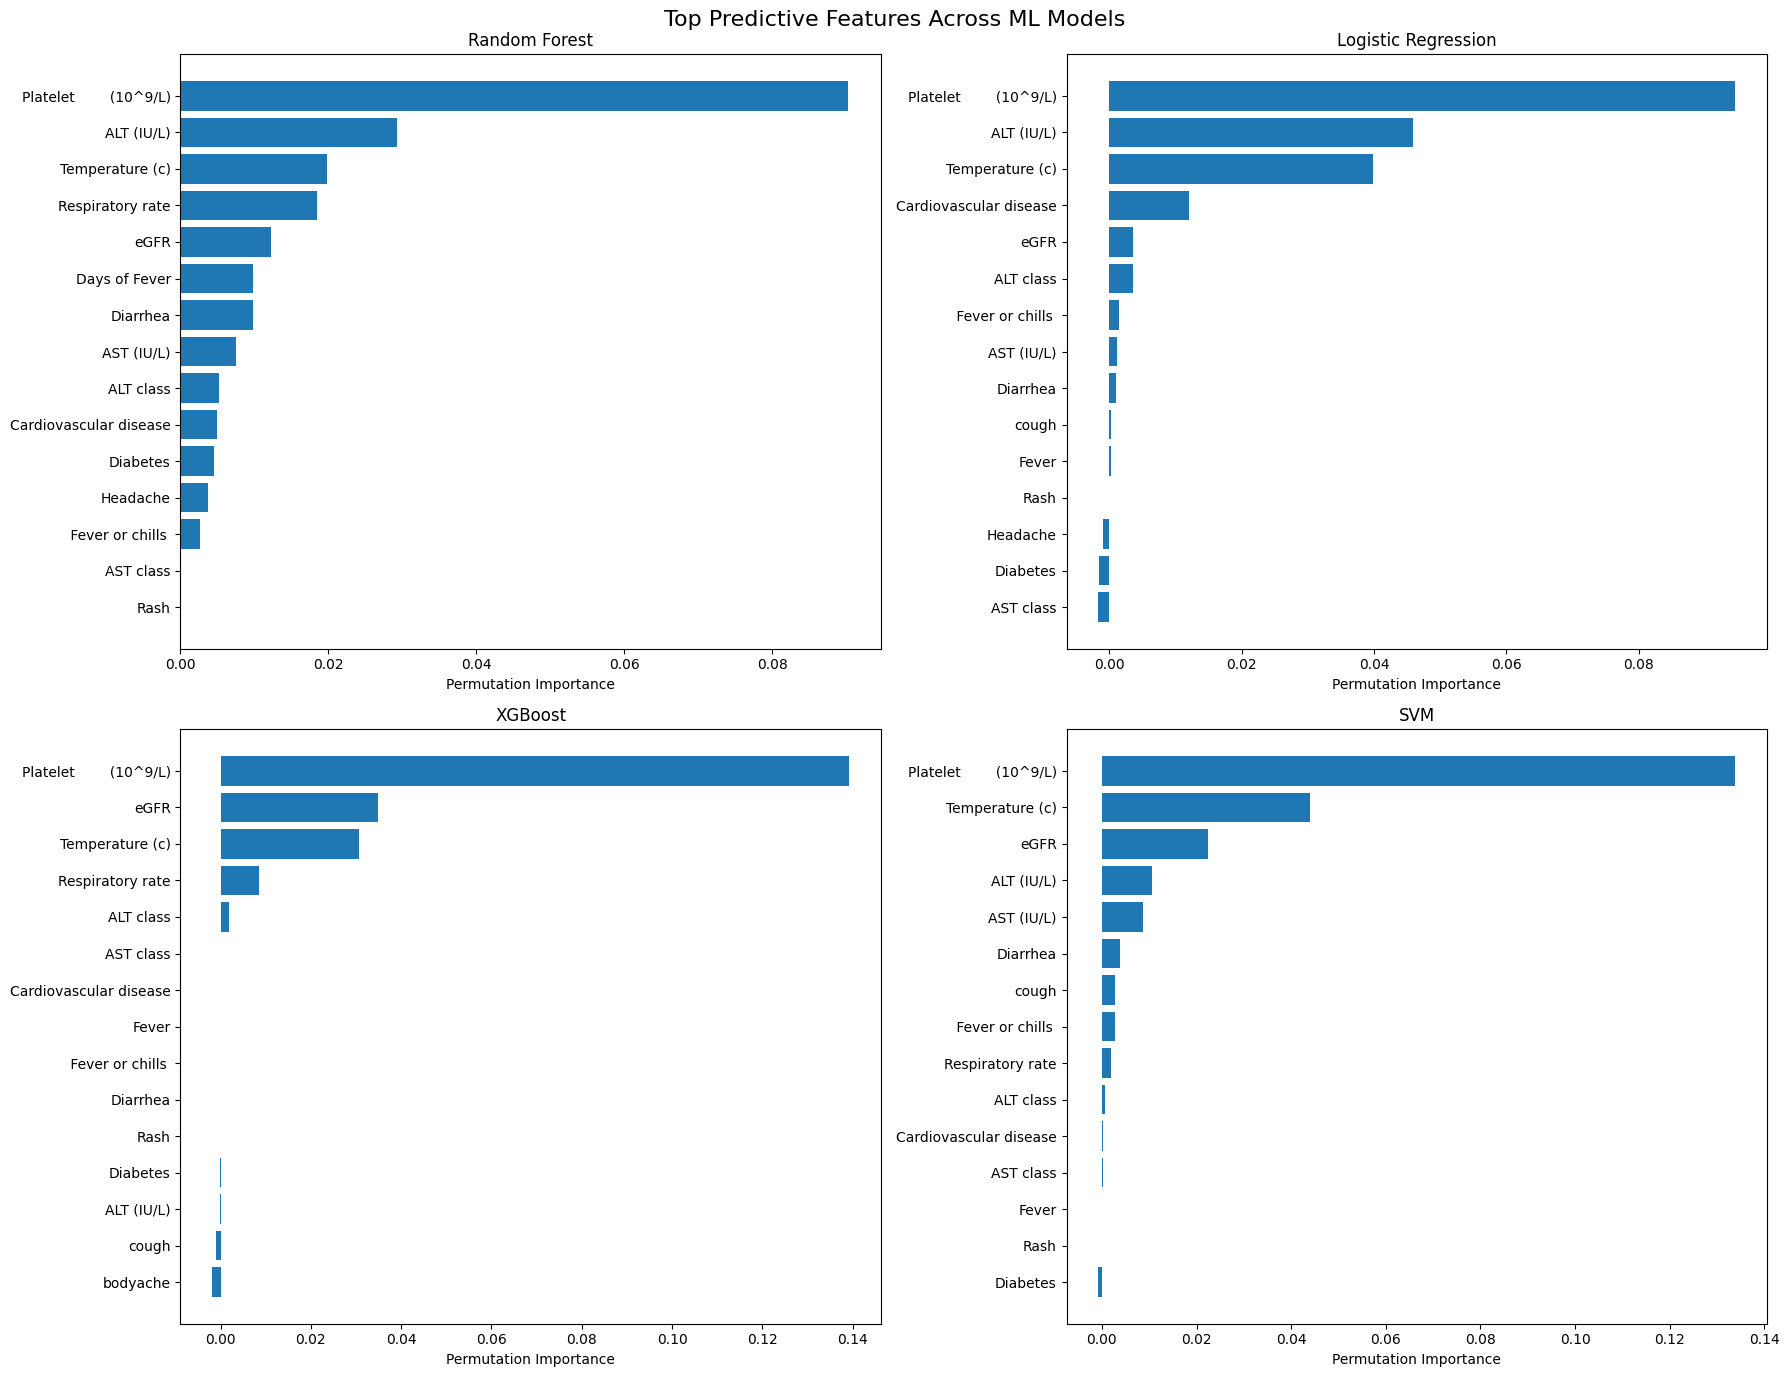

In [67]:
from sklearn.inspection import permutation_importance

# Step 1: Create mapping from cleaned column names (back to original Excel column names)

cleaned_columns_from_original = (
    pd.Series(original_columns)
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", "_", regex=True)
    .str.replace(r"[^\w]", "_", regex=True)
    .str.replace(r"_+", "_", regex=True)
    .str.strip("_")
    .tolist()
)

clean_to_original = dict(zip(cleaned_columns_from_original, original_columns))

# Step 2: Define selected models

models_importance = {
    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ),

    "SVM": SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    )
}

# Step 3: Calculate permutation importance

importance_tables = {}

for name, model in models_importance.items():

    clf = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    clf.fit(X_train, y_train)

    result = permutation_importance(
        clf,
        X_test,
        y_test,
        scoring="roc_auc",
        n_repeats=20,
        random_state=42
    )

    importance_df = pd.DataFrame({
        "Feature_cleaned": X_test.columns,
        "Feature_original": [
            clean_to_original.get(col, col) for col in X_test.columns
        ],
        "Importance": result.importances_mean,
        "SD": result.importances_std
    }).sort_values("Importance", ascending=False)

    importance_tables[name] = importance_df

    print("\n" + "="*70)
    print(name)
    print("="*70)
    display(importance_df.head(20))

# Step 4: Plot top 15 features for each model in 2 x 2 format

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.ravel()

for ax, (name, importance_df) in zip(axes, importance_tables.items()):

    top = importance_df.head(15).sort_values("Importance")

    ax.barh(
        top["Feature_original"],
        top["Importance"]
    )

    ax.set_title(name)
    ax.set_xlabel("Permutation Importance")

plt.suptitle(
    "Top Predictive Features Across ML Models",
    fontsize=16
)

plt.tight_layout()
plt.show()

**Step 17 — Cross-validation**

In [68]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
cv_results = []
cv_scores = {}          # <-- Store every fold score

for name, model in models.items():
    clf = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    scores = cross_val_score(
        clf,
        X_fixed,
        y,
        cv=cv,
        scoring="roc_auc"
    )
    cv_scores[name] = scores

    cv_results.append({
        "Model": name,
        "Mean_ROC_AUC": scores.mean(),
        "SD_ROC_AUC": scores.std()
    })

cv_results_df = (
    pd.DataFrame(cv_results)
      .sort_values("Mean_ROC_AUC", ascending=False)
)

cv_results_df

,Model,Mean_ROC_AUC,SD_ROC_AUC
0,Logistic Regression,0.688270,0.056482
2,Random Forest,0.681433,0.073364
3,SVM,0.674627,0.076220
5,Naive Bayes,0.673247,0.108722
6,XGBoost,0.667767,0.102671
4,kNN,0.638956,0.105953
1,Decision Tree,0.576890,0.061037


# **Interpretation:**
**The key point is that ROC-AUC tells you how well a model separates the two classes (e.g., PCR positive vs PCR negative). A value of 0.5 means the model is no better than random guessing, while 1.0 means perfect discrimination.**

After excluding non-preferred variables including year, aim, age, weight, population density, and humidity, five-fold stratified cross-validation showed that Logistic Regression achieved the highest mean ROC-AUC of 0.688 ± 0.056, followed closely by Random Forest with 0.681 ± 0.073 and SVM with 0.675 ± 0.076. These findings indicate that routine clinical and laboratory variables retain moderate discriminatory ability for predicting DENV qRT-PCR positivity. Logistic Regression was selected as the preferred model because it showed the highest cross-validated ROC-AUC, relatively low variability, and better interpretability.

Among the evaluated classifiers, Logistic Regression achieved the highest five-fold cross-validated ROC-AUC of 0.688 ± 0.056, indicating moderate discrimination between DENV PCR-positive and PCR-negative patients. Random Forest and SVM showed comparable but slightly lower performance, with ROC-AUC values of 0.681 ± 0.073 and 0.675 ± 0.076, respectively. More complex models, including XGBoost and kNN, did not improve performance, suggesting that the available clinical and laboratory predictors may not support highly nonlinear classification in this modest-sized dataset. Decision Tree showed limited discriminatory ability and was not suitable as a final model. Overall, the findings suggest that selected clinical and laboratory features contain a measurable but moderate signal for PCR-confirmed dengue infection. However, the observed performance is insufficient for standalone diagnosis and should instead be considered as an exploratory framework for diagnostic support or prioritization of molecular testing.

**Figure 7. Mean ROC-AUC ± Standard Deviation**

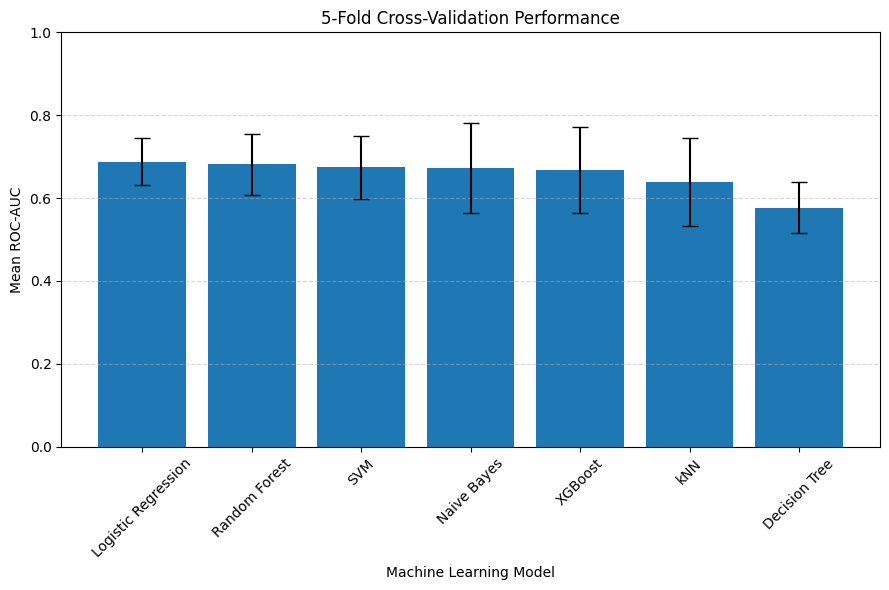

In [69]:
plt.figure(figsize=(9,6))

plt.bar(
    cv_results_df["Model"],
    cv_results_df["Mean_ROC_AUC"],
    yerr=cv_results_df["SD_ROC_AUC"],
    capsize=6
)

plt.ylabel("Mean ROC-AUC")
plt.xlabel("Machine Learning Model")
plt.title("5-Fold Cross-Validation Performance")

plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**Figure 8. ROC-AUC Boxplot Across Folds**

Interpretation:

* Smaller box = more stable model.
* Higher median = better model.
* Smaller whiskers = lower variability.

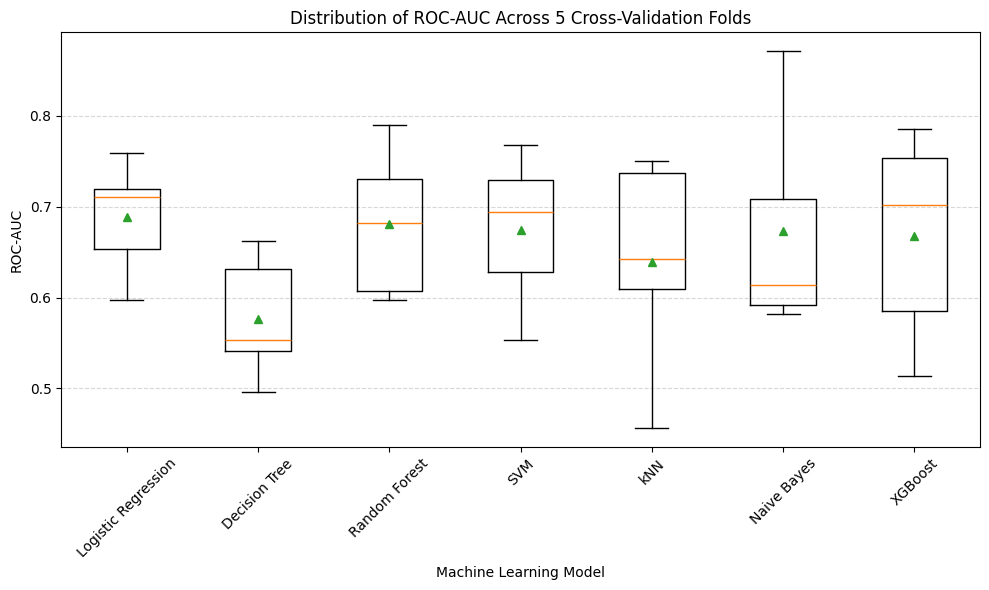

In [70]:
# This shows how stable each model is across the five folds.

plt.figure(figsize=(10,6))
plt.boxplot(
    [cv_scores[m] for m in cv_scores.keys()],
    tick_labels=cv_scores.keys(),
    showmeans=True
)
plt.ylabel("ROC-AUC")
plt.xlabel("Machine Learning Model")
plt.title("Distribution of ROC-AUC Across 5 Cross-Validation Folds")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Figure 9. Model Stability Comparison**

It tells:

* which model has the highest ROC-AUC;
* which model has the smallest standard deviation;
* the trade-off between performance and stability.

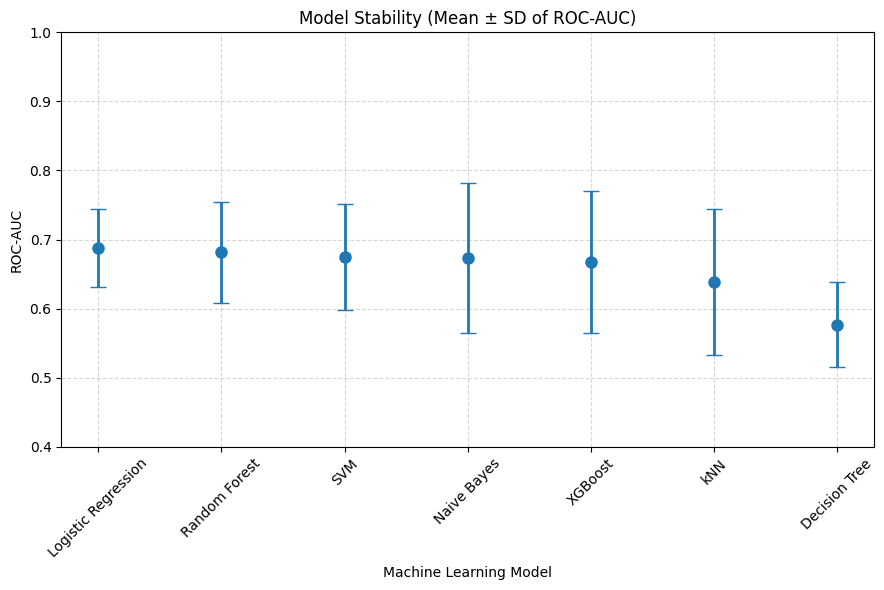

In [71]:
plt.figure(figsize=(9,6))

plt.errorbar(
    cv_results_df["Model"],
    cv_results_df["Mean_ROC_AUC"],
    yerr=cv_results_df["SD_ROC_AUC"],
    fmt="o",
    capsize=6,
    linewidth=2,
    markersize=8
)
plt.ylabel("ROC-AUC")
plt.xlabel("Machine Learning Model")
plt.title("Model Stability (Mean ± SD of ROC-AUC)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.ylim(0.4,1.0)
plt.tight_layout()
plt.show()

**Figure 10. Fold-wise ROC-AUC**

This highlights whether a model performs consistently across folds or has unusually high or low performance in specific folds.

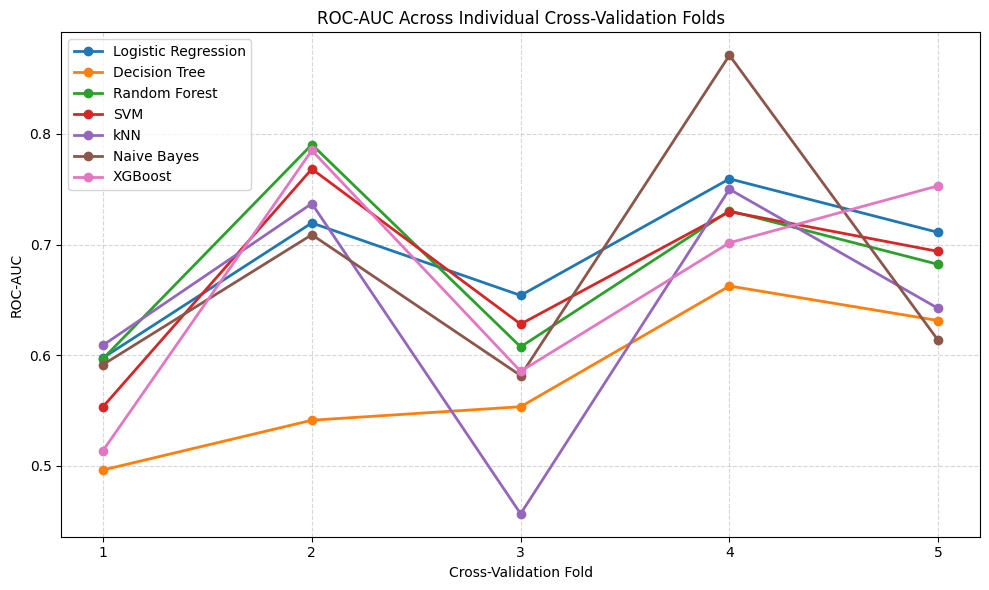

In [72]:
cv_plot = pd.DataFrame(cv_scores)

plt.figure(figsize=(10,6))
for model in cv_plot.columns:
    plt.plot(
        range(1,6),
        cv_plot[model],
        marker="o",
        linewidth=2,
        label=model
    )
plt.xlabel("Cross-Validation Fold")
plt.ylabel("ROC-AUC")
plt.title("ROC-AUC Across Individual Cross-Validation Folds")
plt.xticks(range(1,6))
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

**Figure 11. Ranked Mean ROC-AUC**

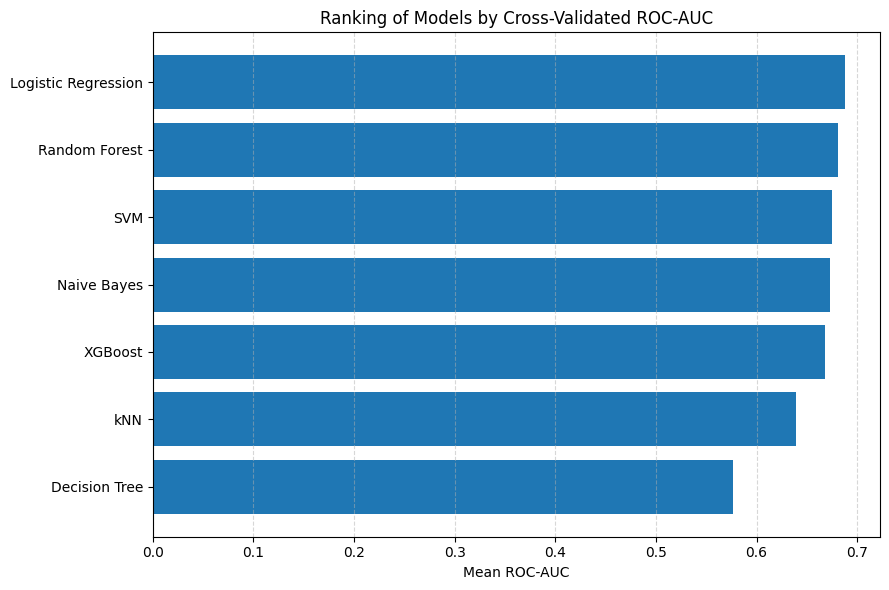

In [73]:
cv_results_df = cv_results_df.sort_values(
    "Mean_ROC_AUC",
    ascending=True
)
plt.figure(figsize=(9,6))
plt.barh(
    cv_results_df["Model"],
    cv_results_df["Mean_ROC_AUC"]
)
plt.xlabel("Mean ROC-AUC")
plt.title("Ranking of Models by Cross-Validated ROC-AUC")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

**Figure 12. PCA analysis: PCR-positive vs PCR-negative**

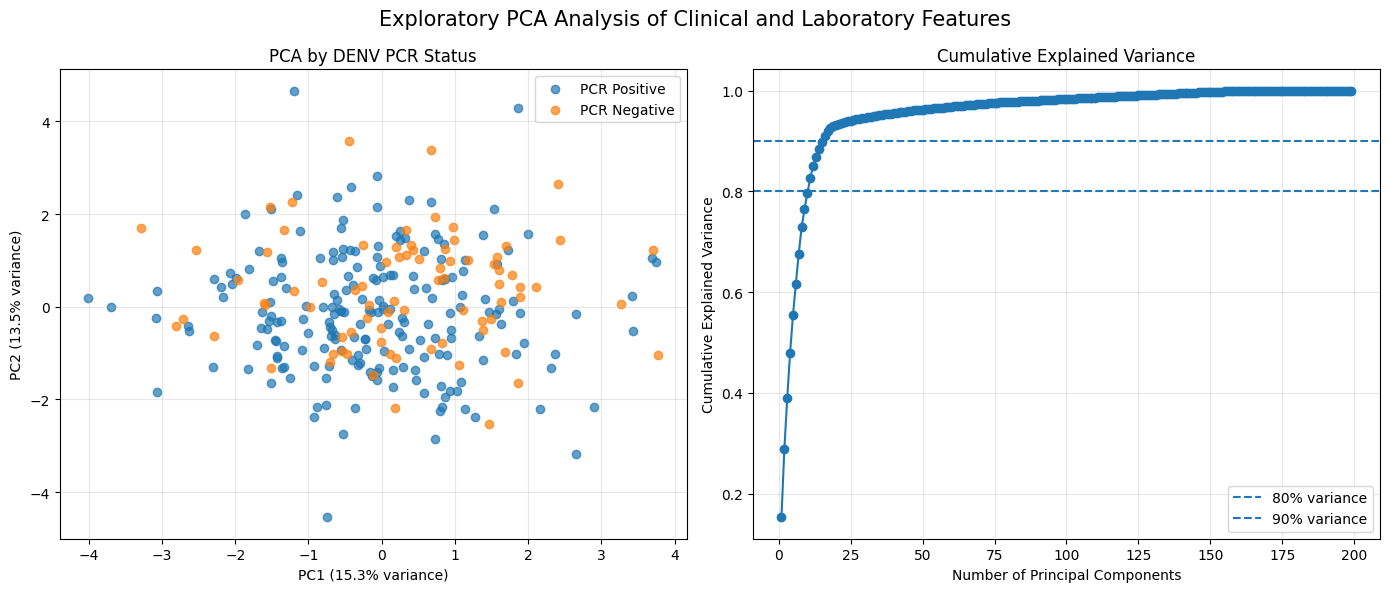

In [74]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# PCA-only dataset: remove study-design variables
# ---------------------------------------------------------

X_pca_clinical = X_fixed.drop(columns=["year", "aim"], errors="ignore")

# Recreate numeric and categorical features for PCA dataset
numeric_features_pca = X_pca_clinical.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features_pca = X_pca_clinical.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

# Build PCA-specific preprocessor
numeric_transformer_pca = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_pca = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_pca = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_pca, numeric_features_pca),
        ("cat", categorical_transformer_pca, categorical_features_pca)
    ],
    sparse_threshold=0
)

# Transform features
X_processed = preprocessor_pca.fit_transform(X_pca_clinical)

# PCA for 2D visualization
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_processed)

# Full PCA for cumulative explained variance
pca_full = PCA()
pca_full.fit(X_processed)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# PCA dataframe
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "PCR_status": y.map({
        0: "PCR Negative",
        1: "PCR Positive"
    })
})

# ---------------------------------------------------------
# Combined 1 x 2 PCA figure
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA scatter plot
for status in pca_df["PCR_status"].unique():
    subset = pca_df[pca_df["PCR_status"] == status]
    axes[0].scatter(
        subset["PC1"],
        subset["PC2"],
        label=status,
        alpha=0.7
    )

axes[0].set_xlabel(
    f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)"
)
axes[0].set_ylabel(
    f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)"
)
axes[0].set_title("PCA by DENV PCR Status")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Cumulative explained variance plot
axes[1].plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

axes[1].axhline(y=0.80, linestyle="--", label="80% variance")
axes[1].axhline(y=0.90, linestyle="--", label="90% variance")

axes[1].set_xlabel("Number of Principal Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("Cumulative Explained Variance")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(
    "Exploratory PCA Analysis of Clinical and Laboratory Features",
    fontsize=15
)

plt.tight_layout()
plt.show()

In [75]:
# ---------------------------------------------------------
# PCA loading table
# ---------------------------------------------------------

feature_names_pca = preprocessor_pca.get_feature_names_out()

loadings_df = pd.DataFrame(
    pca_2d.components_.T,
    columns=["PC1_loading", "PC2_loading"],
    index=feature_names_pca
)

loadings_df["PC1_abs"] = loadings_df["PC1_loading"].abs()
loadings_df["PC2_abs"] = loadings_df["PC2_loading"].abs()

print("Top contributors to PC1:")
display(loadings_df.sort_values("PC1_abs", ascending=False).head(15))

print("Top contributors to PC2:")
display(loadings_df.sort_values("PC2_abs", ascending=False).head(15))

Top contributors to PC1:


,PC1_loading,PC2_loading,PC1_abs,PC2_abs
num__diastolic_blood_pressure,0.544050,-0.328504,0.544050,0.328504
num__systolic_blood_pressure,0.538167,-0.342309,0.538167,0.342309
num__hemotocrit,0.383496,-0.159190,0.383496,0.159190
num__pulse,0.299860,0.369413,0.299860,0.369413
num__platelet_10_9_l,0.246061,0.474682,0.246061,0.474682
num__respiratory_rate,0.217646,0.428017,0.217646,0.428017
num__temperature_c,0.138854,0.215426,0.138854,0.215426
num__ast_iu_l,-0.118804,-0.202704,0.118804,0.202704
num__days_of_fever,-0.098464,-0.282458,0.098464,0.282458
cat__egfr_No,0.084129,0.118225,0.084129,0.118225


Top contributors to PC2:


,PC1_loading,PC2_loading,PC1_abs,PC2_abs
num__platelet_10_9_l,0.246061,0.474682,0.246061,0.474682
num__respiratory_rate,0.217646,0.428017,0.217646,0.428017
num__pulse,0.299860,0.369413,0.299860,0.369413
num__systolic_blood_pressure,0.538167,-0.342309,0.538167,0.342309
num__diastolic_blood_pressure,0.544050,-0.328504,0.544050,0.328504
num__days_of_fever,-0.098464,-0.282458,0.098464,0.282458
num__temperature_c,0.138854,0.215426,0.138854,0.215426
num__ast_iu_l,-0.118804,-0.202704,0.118804,0.202704
num__hemotocrit,0.383496,-0.159190,0.383496,0.159190
cat__egfr_No,0.084129,0.118225,0.084129,0.118225


# Main biological interpretation

After performing five-fold stratified cross-validation, the results show that the clinical-feature model has moderate but not strong discriminatory ability for predicting DENV PCR positivity. Logistic Regression achieved the highest mean ROC-AUC of 0.688 ± 0.056, followed closely by Random Forest (0.681 ± 0.073) and SVM (0.675 ± 0.076). This indicates that selected clinical and laboratory features can distinguish PCR-positive from PCR-negative patients better than chance, but the performance remains below the level required for a reliable standalone diagnostic model. The relatively small difference between Logistic Regression, Random Forest, and SVM suggests that no model is overwhelmingly superior; however, Logistic Regression appears preferable because it combines the highest mean ROC-AUC with lower variability and better interpretability.

The bar plot and model-stability figure show that most models cluster around ROC-AUC values of approximately 0.65-0.69, confirming that the dataset contains a real but limited predictive signal. The boxplot and fold-wise ROC-AUC plot further show that model performance varies across folds, especially for Naive Bayes, XGBoost, and kNN, which have wider variability. Logistic Regression appears more consistent across folds, while Decision Tree performs the weakest, with a mean ROC-AUC of 0.577, close to random classification. This suggests that a single tree is not adequate for this dataset and may fail to capture the multivariable clinical pattern associated with PCR positivity.

The PCA figure supports the same conclusion. The first two principal components explain only 15.3% and 13.5% of the variance, respectively, and the PCR-positive and PCR-negative cases show substantial overlap. This means that the two groups are not naturally separated in a simple two-dimensional clinical/laboratory space. The cumulative explained variance plot shows that many components are required to capture most of the dataset's variance, indicating that the predictive information is distributed across multiple variables rather than dominated by one or two features. Therefore, PCA supports the use of multivariable supervised models, but also explains why the final ROC-AUC remains moderate rather than high.

Overall, these post-cross-validation results suggest that routine clinical and laboratory variables contain a measurable but moderate diagnostic signal for DENV PCR positivity. Logistic Regression should be reported as the preferred final model because it achieved the best cross-validated performance and is easier to interpret clinically. However, the model should be described as an exploratory diagnostic-support tool, not as a replacement for qRT-PCR. The main conclusion is that clinical/laboratory profiles can help prioritize or support dengue testing, but molecular confirmation remains necessary.

The PCA suggests that the major variation among patients is driven by:

1. blood pressure
2. platelet count
3. hematocrit
4. pulse
5. respiratory rate
6. temperature
7. AST
8. days of fever
9. eGFR

So PCA supports the ML finding that the dataset contains a meaningful clinical/laboratory structure related to dengue-like illness.

However, PCA does not tell us which variables predict PCR positivity most strongly. It only tells us which variables explain the largest overall variation in the dataset.

For example:

* A variable can be important in PCA but not predictive of PCR status.
* A variable can be predictive of PCR status but not dominate PCA.
* PCA is unsupervised, so it does not know the PCR-positive/PCR-negative labels.

# **Thank you**


---


If you reached till here... You should celebrate